In [5]:
import numpy as np 
import torch, torchvision
import torch.nn as nn 
import torch.nn.functional as F 
import torchvision.transforms as transforms 
import matplotlib.pyplot as plt 
import torch.optim as optim 
from torch.utils.data import DataLoader 

In [2]:
torch.manual_seed(20)

In [3]:
if torch.cuda.is_available():
    device = 'cuda'
    print('cuda available')
else:
    device = 'cpu'
    print('only cpu available')

cuda available


In [6]:
learning_rate = 1e-3

In [7]:
train_batch = 4
test_batch = 4

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
trainloader = torch.utils.data.DataLoader(trainset, batch_size=train_batch, shuffle=True, num_workers=2)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())
testloader = torch.utils.data.DataLoader(testset, batch_size=test_batch, shuffle=False, num_workers=2)

In [8]:
mean = trainset.data.float().mean()
std = trainset.data.float().std()

tform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean / 255.0], std=[std / 255.0])
])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=tform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=tform)

In [10]:
len(trainset), len(testset)

(60000, 10000)

In [11]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=train_batch, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=test_batch, shuffle=False, num_workers=2)

In [13]:
len(trainloader), len(testloader) 

(15000, 2500)

In [14]:
class VAE_linear(nn.Module):
    def __init__(self, in_features, hidden_dims, out_features, bias=True):
        super().__init__() 
        self.encoder = nn.Linear(in_features, hidden_dims, bias=bias)
        self.decoder = nn.Linear(hidden_dims, out_features, bias=bias) 

    def forward(self, x):
        output = self.encoder(x)
        output = F.relu(output)
        output = self.decoder(output)
        output = F.relu(output) 
        return output 

In [15]:
vae = VAE_linear(28*28, 100, 28*28)

In [18]:
# let's check -- before training, the output should be noise 
example_data, example_label = next(iter(trainloader))
len(example_data), len(example_label)

(4, 4)

In [20]:
example_data.shape 

torch.Size([4, 1, 28, 28])

In [21]:
example_label 

tensor([0, 7, 5, 6])

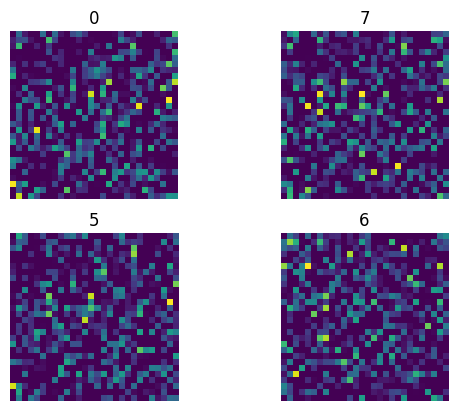

In [29]:
output = vae(example_data.reshape(example_data.shape[0], -1))

plt.figure() 

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(output[i].detach().numpy().reshape(28, 28))
    plt.title(f'{example_label[i]}') 
    plt.axis('off') 

In [32]:
vae.to(device)
optimizer = optim.SGD(params=vae.parameters(), lr=learning_rate)
loss_fn = F.mse_loss 
train_loss = []
test_loss = [] 

In [33]:
def train():
    vae.train() 
    running_loss = 0 

    for data, label in trainloader:
        data, label = data.to(device), label.to(device)

        # forward pass 
        logits = vae(data.view(data.shape[0], -1)) 
        loss = loss_fn(logits, data.view(data.shape[0], -1)) 
        
        # backward
        optimizer.zero_grad() 
        loss.backward() 
        optimizer.step() 

        running_loss += loss.item() 

    train_loss.append(running_loss / len(trainloader))

In [34]:
def test():
    vae.eval() 
    running_loss = 0 

    with torch.no_grad():
        for data, label in testloader:
            data, lebel = data.to(device), label.to(device)
            logits = vae(data.view(data.shape[0], -1)) 
            loss = loss_fn(logits, data.view(data.shape[0], -1)) 
            running_loss += loss.item() 

    test_loss.append(running_loss / len(testloader))

In [ ]:
n_epochs = 100 

for epochI in range(n_epochs):
    print(f'epoch {epochI}')
    train() 
    test() 

epoch 0


In [36]:
train_loss 

[0.8850864815274875,
 0.7603398771127065,
 0.6903283907850584,
 0.6269472705841065,
 0.5746094166676203,
 0.5378237340609232,
 0.511274520623684,
 0.4907040029346943,
 0.4749774367829164,
 0.4614175506790479,
 0.44995367620388665,
 0.44052756716012953,
 0.4325147150059541,
 0.4255749585390091,
 0.41942032720247907,
 0.4135415179073811,
 0.4083100719332695,
 0.4037991183658441,
 0.3998132240513961,
 0.3962258040070534,
 0.3929330216864745,
 0.38871956964532534,
 0.38315277612805365,
 0.3795053283393383,
 0.3767130205333233,
 0.37430341181755067,
 0.3721352533598741,
 0.37015237282514574,
 0.36832161901990573,
 0.3666219012737274,
 0.36502739578187465,
 0.363492819694678,
 0.3617994192699591,
 0.3601291298180819,
 0.3587088042477767,
 0.3574197568446398,
 0.3562225380758444,
 0.35509432978332045,
 0.3540295517603556,
 0.3530216822326183,
 0.3520650813976924,
 0.3511555510987838,
 0.3502804793467124,
 0.34940994295179845,
 0.34847689627905687,
 0.347489909662803,
 0.3463753141740958,
 0.3

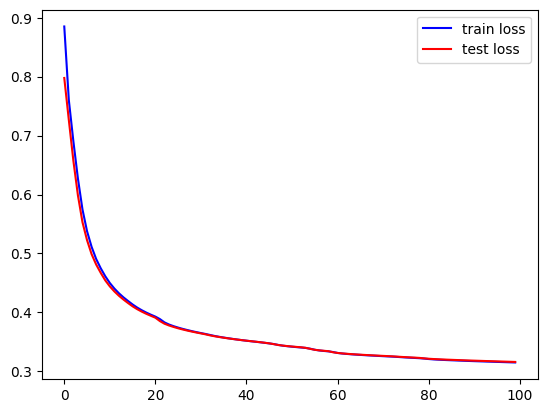

In [40]:
plt.figure()

plt.plot(train_loss, color='b', label='train loss')
plt.plot(test_loss, color='r', label='test loss')
plt.legend() 

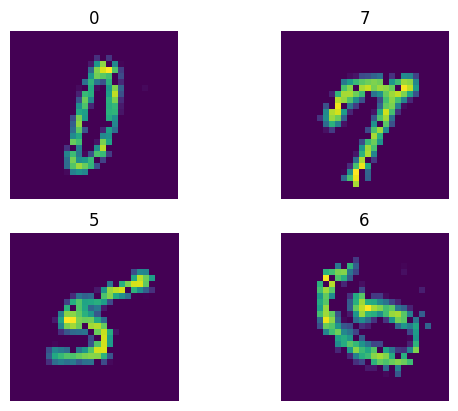

In [39]:
output = vae(example_data.to(device).reshape(example_data.shape[0], -1))

plt.figure() 

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(output[i].cpu().detach().numpy().reshape(28, 28))
    plt.title(f'{example_label[i]}') 
    plt.axis('off') 